# Monte Carlo–Informed A/B Study: NQ Futures TP/SL Optimization

**Author:** Sydney Horton | **Status:** In Progress | **Date:** Oct 2025

## Overview
Prospective randomized A/B trial comparing two reward-to-risk configurations
in Nasdaq-100 futures trading across 100 simulated trades.

| | Arm A | Arm B |
|---|---|---|
| Take-profit | $300 | $150 |
| Stop-loss | $150 | $100 |
| R:R ratio | 2.0 | 1.5 |

**Tests applied:** Welch's t-test · Mann-Whitney U · Bootstrap CI (n=5,000) · Cohen's d

In [ ]:

import random, pandas as pd, numpy as np

# Parameters
win_rate_A, win_rate_B = 0.54, 0.58
avg_win_A, avg_loss_A = 300, 150
avg_win_B, avg_loss_B = 150, 100
trades_per_day = 5
days = 20

results = []

for d in range(days):
    for t in range(trades_per_day):
        arm = random.choice(["A","B"])
        win_rate = win_rate_A if arm=="A" else win_rate_B
        avg_win   = avg_win_A if arm=="A" else avg_win_B
        avg_loss  = avg_loss_A if arm=="A" else avg_loss_B

        result = np.random.choice(
            [avg_win, -avg_loss],
            p=[win_rate, 1-win_rate]
        )
        results.append({"day": d+1, "trade": t+1, "arm": arm, "pnl": result})

df = pd.DataFrame(results)
print(df.head())

# Summary
summary = df.groupby("arm")["pnl"].agg(["mean","std","count"])
print("\nSummary:\n", summary)


   day  trade arm  pnl
0    1      1   A -150
1    1      2   A -150
2    1      3   B  150
3    1      4   B  150
4    1      5   B  150

Summary:
      mean         std  count
arm                         
A    93.0  226.555845     50
B    70.0  117.803018     50


In [ ]:
!pip install pandas numpy matplotlib scipy
import random, pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats

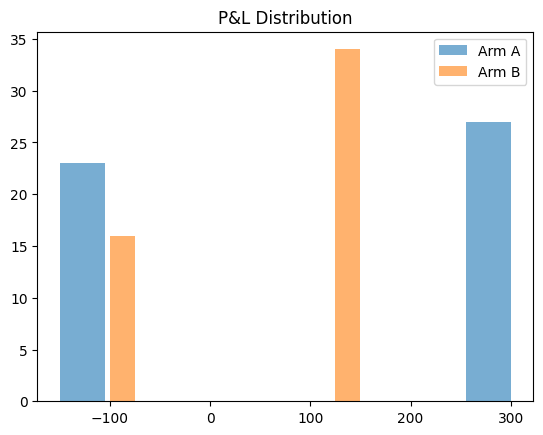

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df[df.arm=="A"].pnl, alpha=0.6, label="Arm A")
plt.hist(df[df.arm=="B"].pnl, alpha=0.6, label="Arm B")
plt.legend(); plt.title("P&L Distribution"); plt.show()

In [ ]:
!pip install openpyxl
df.to_excel("ab_results.xlsx", index=False)
from google.colab import files
files.download("ab_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.value_counts(["arm","pnl"])

arm  pnl 
B     150    34
A     300    27
     -150    23
B    -100    16
Name: count, dtype: int64

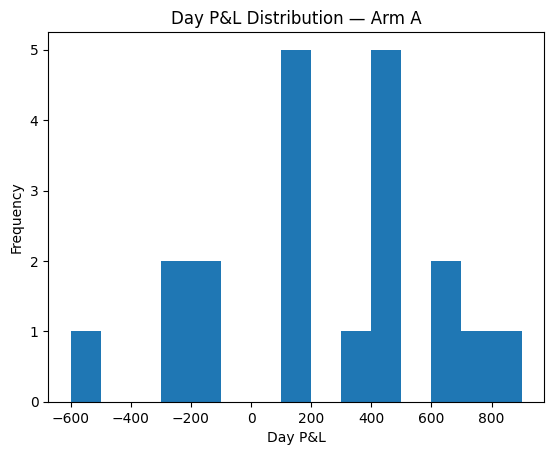

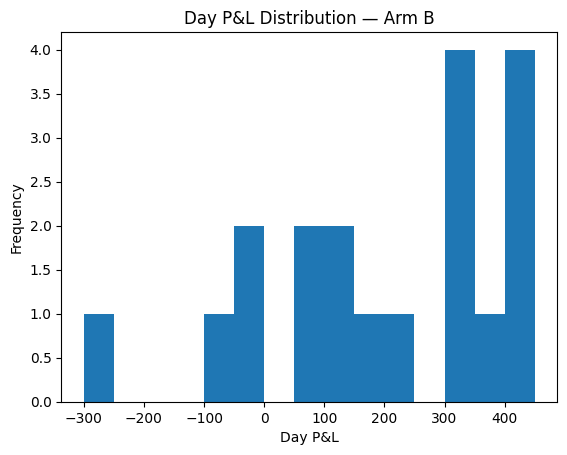

In [ ]:
day_totals = df.groupby(["arm","day"])["pnl"].sum().reset_index()
import matplotlib.pyplot as plt

for arm in ["A","B"]:
    plt.figure()
    plt.hist(day_totals[day_totals.arm==arm].pnl, bins=15)
    plt.title(f"Day P&L Distribution — Arm {arm}")
    plt.xlabel("Day P&L"); plt.ylabel("Frequency"); plt.show()


In [ ]:
two_week_totals = df.groupby("arm")["pnl"].sum()
print("Two-week totals:\n", two_week_totals)


Two-week totals:
 arm
A    4650
B    3500
Name: pnl, dtype: int64


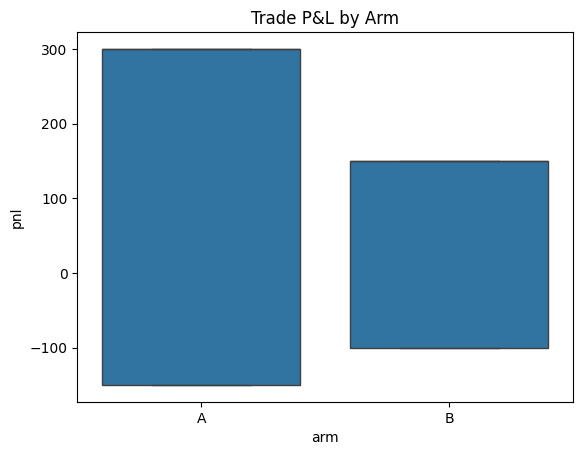

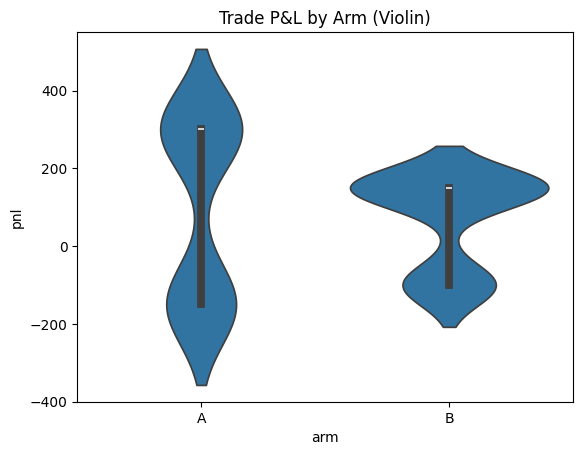

In [ ]:
import seaborn as sns
sns.boxplot(data=df, x="arm", y="pnl"); plt.title("Trade P&L by Arm"); plt.show()
sns.violinplot(data=df, x="arm", y="pnl"); plt.title("Trade P&L by Arm (Violin)"); plt.show()


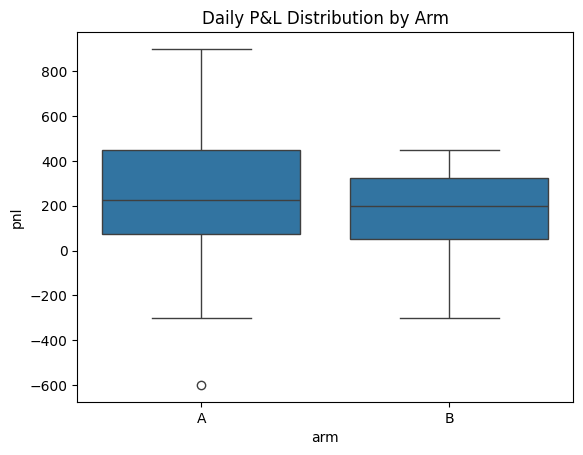

In [ ]:
day_totals = df.groupby(["arm","day"])["pnl"].sum().reset_index()
import seaborn as sns
sns.boxplot(data=day_totals, x="arm", y="pnl")
plt.title("Daily P&L Distribution by Arm")
plt.show()

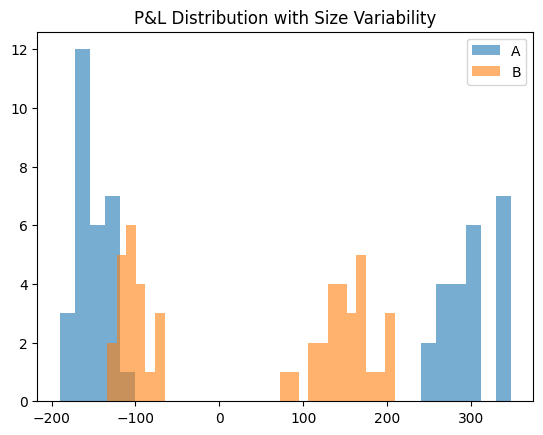

In [ ]:
# Example: wins/losses vary ~ normal around your targets (clipped to avoid extremes)
rng = np.random.default_rng(0)
def jittered_outcome(avg_win, avg_loss, win_rate, sd_win=30, sd_loss=20):
    if rng.random() < win_rate:
        return float(np.clip(rng.normal(avg_win, sd_win), 0, avg_win*1.5))
    else:
        return -float(np.clip(rng.normal(avg_loss, sd_loss), 0, avg_loss*1.5))

results = []
for d in range(20):
    for t in range(5):
        arm = random.choice(["A","B"])
        wr   = 0.54 if arm=="A" else 0.58
        aw   = 300  if arm=="A" else 150
        al   = 150  if arm=="A" else 100
        results.append({"day": d+1, "trade": t+1, "arm": arm,
                        "pnl": jittered_outcome(aw, al, wr)})
df_var = pd.DataFrame(results)

plt.hist(df_var[df_var.arm=="A"].pnl, bins=30, alpha=.6, label="A")
plt.hist(df_var[df_var.arm=="B"].pnl, bins=30, alpha=.6, label="B")
plt.legend(); plt.title("P&L Distribution with Size Variability"); plt.show()


In [ ]:
# trade-level
desc_trade = df.groupby("arm")["pnl"].agg(['count','mean','median','std','sum'])
# win rate & profit factor
win_rate = df.assign(win=(df.pnl>0)).groupby("arm")["win"].mean()
pf = (df[df.pnl>0].groupby("arm")["pnl"].sum() / (-df[df.pnl<0].groupby("arm")["pnl"].sum()))
print(desc_trade, "\n\nWin rate:\n", win_rate, "\n\nProfit factor:\n", pf)


     count  mean  median         std   sum
arm                                       
A       50  93.0   300.0  226.555845  4650
B       50  70.0   150.0  117.803018  3500 

Win rate:
 arm
A    0.54
B    0.68
Name: win, dtype: float64 

Profit factor:
 arm
A    2.347826
B    3.187500
Name: pnl, dtype: float64


In [ ]:
day_totals = df.groupby(["arm","day"])["pnl"].sum().reset_index()
desc_day = day_totals.groupby("arm")["pnl"].agg(['count','mean','median','std'])
pos_day = (day_totals.assign(pos=day_totals.pnl>0)
           .groupby("arm")["pos"].mean())
print(desc_day, "\n\n% Positive days:\n", pos_day)



     count        mean  median         std
arm                                       
A       20  232.500000   225.0  384.664926
B       19  184.210526   200.0  216.058526 

% Positive days:
 arm
A    0.750000
B    0.789474
Name: pos, dtype: float64


In [ ]:
from scipy import stats
A = df.loc[df.arm=="A","pnl"].values
B = df.loc[df.arm=="B","pnl"].values
t_res = stats.ttest_ind(A, B, equal_var=False)
u_res = stats.mannwhitneyu(A, B, alternative='two-sided')
print("Welch t:", t_res, "\nMann–Whitney U:", u_res)


Welch t: TtestResult(statistic=np.float64(0.6369011730062784), pvalue=np.float64(0.5261628722071852), df=np.float64(73.69151168826824)) 
Mann–Whitney U: MannwhitneyuResult(statistic=np.float64(1350.0), pvalue=np.float64(0.4756836067485519))


In [ ]:
import numpy as np
A_pos = (day_totals.query('arm=="A"').pnl>0).sum()
B_pos = (day_totals.query('arm=="B"').pnl>0).sum()
A_n = (day_totals.arm=="A").sum(); B_n = (day_totals.arm=="B").sum()
p1, p2 = A_pos/A_n, B_pos/B_n
p_pool = (A_pos+B_pos)/(A_n+B_n)
z = (p1-p2) / np.sqrt(p_pool*(1-p_pool)*(1/A_n+1/B_n))
from scipy.stats import norm
pval = 2*(1-norm.cdf(abs(z)))
print("Two-proportion z:", z, "p-value:", pval, "rates:", p1, p2)


Two-proportion z: -0.292448825932801 p-value: 0.7699434813302468 rates: 0.75 0.7894736842105263


In [ ]:
rng = np.random.default_rng(0)
def boot_mean(arr, n=5000):
    idx = rng.integers(0, len(arr), (n, len(arr)))
    return arr[idx].mean(axis=1)

boot_A = boot_mean(A); boot_B = boot_mean(B)
diff = boot_A - boot_B
ci = (np.percentile(diff, 2.5), np.percentile(diff, 97.5))
print("Mean diff (A−B):", (A.mean()-B.mean()), "95% CI:", ci)


Mean diff (A−B): 23.0 95% CI: (np.float64(-50.0), np.float64(95.0))


In [ ]:
# Welch's d (uses pooled SD with unequal variances)
s1, s2 = A.std(ddof=1), B.std(ddof=1)
n1, n2 = len(A), len(B)
sp = np.sqrt(((s1**2)*(n1-1) + (s2**2)*(n2-1)) / (n1+n2-2))
d = (A.mean()-B.mean()) / sp
print("Cohen's d:", d)


Cohen's d: 0.1273802346012557


In [ ]:
import statsmodels.api as sm
# Suppose you logged vol_regime (numeric) and trend_regime (one-hot or categorical)
df_reg = df.copy()
# Example: merge day-level regime tags into trade rows first if needed
# df_reg = df_reg.merge(regimes_df, on=['day'], how='left')
X = pd.get_dummies(df_reg[['arm']], drop_first=True)
X['arm_B'] = (df_reg['arm']=="B").astype(int)  # or one-hot above
X = sm.add_constant(X)
y = df_reg['pnl']
print(sm.OLS(y, X).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                    pnl   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.4056
Date:                Wed, 29 Oct 2025   Prob (F-statistic):              0.526
Time:                        20:22:02   Log-Likelihood:                -660.49
No. Observations:                 100   AIC:                             1325.
Df Residuals:                      98   BIC:                             1330.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         93.0000     25.535      3.642      0.0

In [ ]:
import statsmodels.api as sm
# Suppose you logged vol_regime (numeric) and trend_regime (one-hot or categorical)
df_reg = df.copy()
# Example: merge day-level regime tags into trade rows first if needed
# df_reg = df_reg.merge(regimes_df, on=['day'], how='left')
X = pd.get_dummies(df_reg[['arm','vol_regime','trend_regime']], drop_first=True)
X['arm_B'] = (df_reg['arm']=="B").astype(int)  # or one-hot above
X = sm.add_constant(X)
y = df_reg['pnl']
print(sm.OLS(y, X).fit().summary())


KeyError: "['vol_regime', 'trend_regime'] not in index"

In [ ]:
summary = pd.DataFrame({
    "metric": ["trades","mean_trade","median_trade","sd_trade","win_rate","profit_factor",
               "mean_day","median_day","sd_day","pos_day_rate"],
    "A": [desc_trade.loc["A","count"], desc_trade.loc["A","mean"], desc_trade.loc["A","median"],
          desc_trade.loc["A","std"], win_rate.loc["A"], pf.loc["A"],
          desc_day.loc["A","mean"], desc_day.loc["A","median"], desc_day.loc["A","std"],
          pos_day.loc["A"]],
    "B": [desc_trade.loc["B","count"], desc_trade.loc["B","mean"], desc_trade.loc["B","median"],
          desc_trade.loc["B","std"], win_rate.loc["B"], pf.loc["B"],
          desc_day.loc["B","mean"], desc_day.loc["B","median"], desc_day.loc["B","std"],
          pos_day.loc["B"]],
})
summary.to_excel("ab_results_summary.xlsx", index=False)
from google.colab import files; files.download("ab_results_summary.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Convert the summary DataFrame into a formatted plain-text block
text_output = "A/B Trading Study Summary Table\n\n"
text_output += "{:<15} {:>15} {:>15}\n".format("Metric", "Arm A", "Arm B")
text_output += "-"*45 + "\n"

for i, row in summary.iterrows():
    text_output += "{:<15} {:>15.2f} {:>15.2f}\n".format(
        row['metric'], row['A'], row['B']
    )

print(text_output)


A/B Trading Study Summary Table

Metric                    Arm A           Arm B
---------------------------------------------
trades                    50.00           50.00
mean_trade                93.00           70.00
median_trade             300.00          150.00
sd_trade                 226.56          117.80
win_rate                   0.54            0.68
profit_factor              2.35            3.19
mean_day                 232.50          184.21
median_day               225.00          200.00
sd_day                   384.66          216.06
pos_day_rate               0.75            0.79



In [ ]:
# Assume each trade loses a fixed amount to slippage + commissions
SLIPPAGE = 10     # dollars per trade (≈2 ticks)
COMMISSION = 5    # dollars per trade
FRICTION_COST = SLIPPAGE + COMMISSION

df_friction = df.copy()
df_friction["pnl_adj"] = df_friction["pnl"] - FRICTION_COST

# Compare summary statistics before/after
print("Average P&L loss per trade:", FRICTION_COST)
print("\nOriginal mean:", df['pnl'].mean(),
      "\nAfter friction:", df_friction['pnl_adj'].mean())

# Recalculate per-arm means and profit factor
summary_friction = df_friction.groupby("arm")["pnl_adj"].agg(["mean","std","sum","count"])
print("\nAdjusted summary:\n", summary_friction)


Average P&L loss per trade: 15

Original mean: 81.5 
After friction: 66.5

Adjusted summary:
      mean         std   sum  count
arm                               
A    78.0  226.555845  3900     50
B    55.0  117.803018  2750     50


In [ ]:
rng = np.random.default_rng(42)
def apply_slippage(row):
    # Mean slippage higher for Arm A (larger target = longer exposure)
    base = 8 if row["arm"]=="A" else 5
    noise = rng.normal(0, 3)  # variability
    return max(0, base + noise)

df_slip = df.copy()
df_slip["slippage"] = df_slip.apply(apply_slippage, axis=1)
df_slip["pnl_adj"] = df_slip["pnl"] - (df_slip["slippage"] + 5)  # +$5 commission
df_slip.groupby("arm")["pnl_adj"].describe()


,count,mean,std,min,25%,50%,75%,max
arm,,,,,,,,
A,50.0,80.172935,226.690290,-166.667624,-162.604971,283.988866,287.734967,291.371467
B,50.0,60.109408,117.200481,-113.381724,-106.352596,138.182281,139.763917,145.000000


In [ ]:
# Example: 5% of trades experience severe delay, 10% mild delay
def execution_latency(row):
    p = rng.random()
    if p < 0.05:  # severe
        return row["pnl"] - np.sign(row["pnl"]) * 50
    elif p < 0.15:  # mild
        return row["pnl"] - np.sign(row["pnl"]) * 20
    else:
        return row["pnl"]

df_latency = df.copy()
df_latency["pnl_adj"] = df_latency.apply(execution_latency, axis=1)
df_latency.groupby("arm")["pnl_adj"].agg(["mean","std","sum"])


,mean,std,sum
arm,,,
A,94.4,220.159126,4720
B,68.2,111.752094,3410


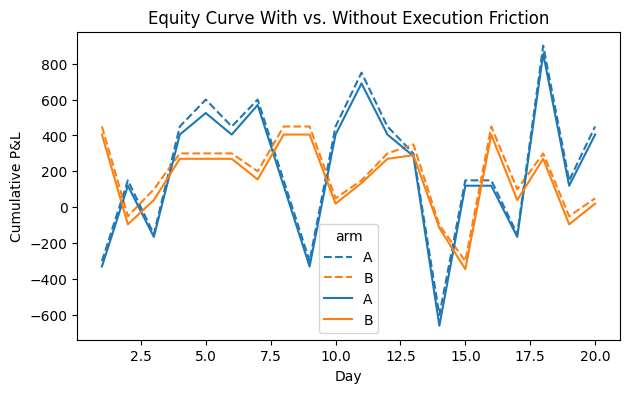

In [ ]:
daily_clean = df.groupby(["arm","day"])["pnl"].sum().reset_index()
daily_fric  = df_friction.groupby(["arm","day"])["pnl_adj"].sum().reset_index()

import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
sns.lineplot(data=daily_clean, x="day", y="pnl", hue="arm", linestyle="--")
sns.lineplot(data=daily_fric, x="day", y="pnl_adj", hue="arm")
plt.title("Equity Curve With vs. Without Execution Friction")
plt.xlabel("Day"); plt.ylabel("Cumulative P&L"); plt.show()